   0   1        2        3        4        5        6        7        8   \
0   1   0  0.99539 -0.05889  0.85243  0.02306  0.83398 -0.37708  1.00000   
1   1   0  1.00000 -0.18829  0.93035 -0.36156 -0.10868 -0.93597  1.00000   
2   1   0  1.00000 -0.03365  1.00000  0.00485  1.00000 -0.12062  0.88965   
3   1   0  1.00000 -0.45161  1.00000  1.00000  0.71216 -1.00000  0.00000   
4   1   0  1.00000 -0.02401  0.94140  0.06531  0.92106 -0.23255  0.77152   

        9   ...       25       26       27       28       29       30  \
0  0.03760  ... -0.51171  0.41078 -0.46168  0.21266 -0.34090  0.42267   
1 -0.04549  ... -0.26569 -0.20468 -0.18401 -0.19040 -0.11593 -0.16626   
2  0.01198  ... -0.40220  0.58984 -0.22145  0.43100 -0.17365  0.60436   
3  0.00000  ...  0.90695  0.51613  1.00000  1.00000 -0.20099  0.25682   
4 -0.16399  ... -0.65158  0.13290 -0.53206  0.02431 -0.62197 -0.05707   

        31       32       33  34  
0 -0.54487  0.18641 -0.45300   g  
1 -0.06288 -0.13738 -0.02447   b  

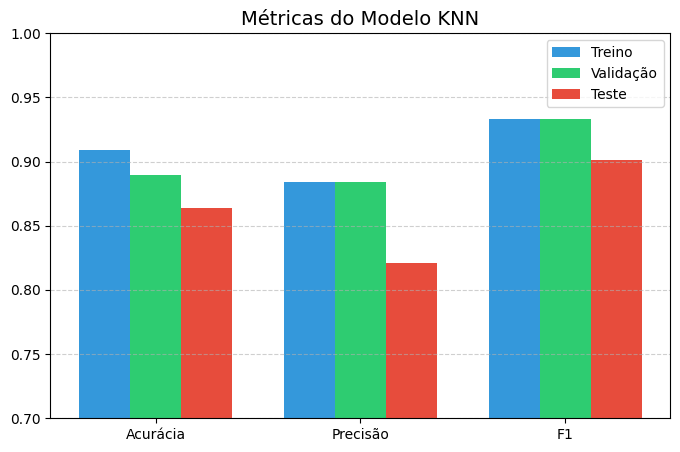

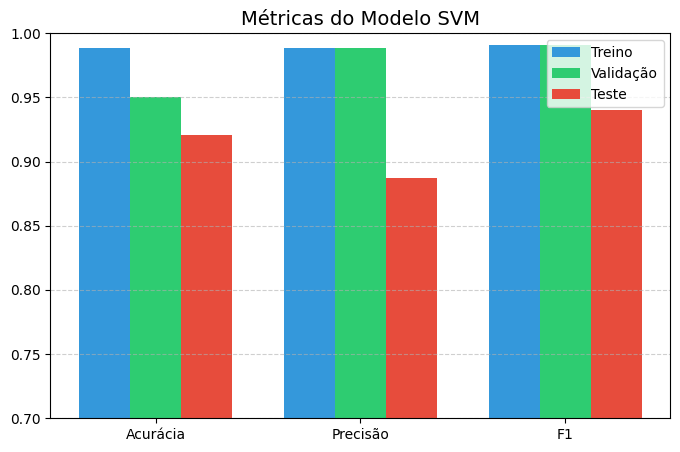

<ipython-input-3-0d146c318286>:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['KNN', 'SVM'], y=[knn_test_metrics['accuracy'], svm_test_metrics['accuracy']], palette='viridis')


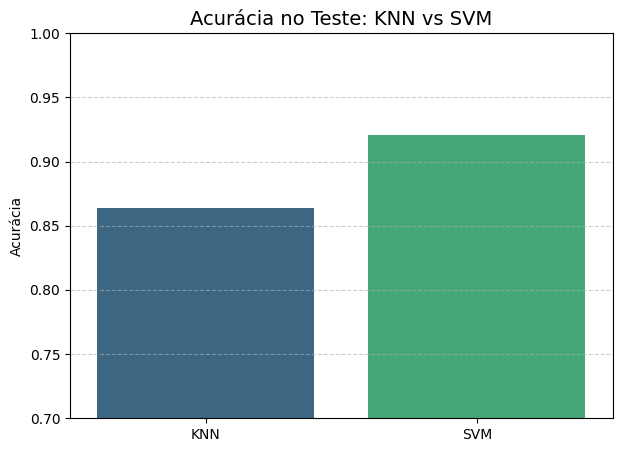

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score, recall_score

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'
data = pd.read_csv(url, header=None)

print(data.head(5))

# divisão de atributos e classe
X = data.iloc[:, 2:-1].values
y = data.iloc[:, -1].values

le = LabelEncoder()
y = le.fit_transform(y)


import matplotlib.pyplot as plt
import seaborn as sns

def plot_metrics(model_name, train_metrics, val_metrics, test_metrics):
    fig, ax = plt.subplots(figsize=(8, 5))
    metrics = ['Acurácia', 'Precisão', 'F1']
    x = range(len(metrics))

    ax.bar(x, [train_metrics['accuracy'], train_metrics['precision'], train_metrics['f1']],
           width=0.25, label='Treino', color='#3498db')
    ax.bar([i + 0.25 for i in x], [val_metrics['accuracy'], val_metrics['precision'], val_metrics['f1']],
           width=0.25, label='Validação', color='#2ecc71')
    ax.bar([i + 0.5 for i in x], [test_metrics['accuracy'], test_metrics['precision'], test_metrics['f1']],
           width=0.25, label='Teste', color='#e74c3c')

    ax.set_title(f'Métricas do Modelo {model_name}', fontsize=14)
    ax.set_xticks([i + 0.25 for i in x])
    ax.set_xticklabels(metrics)
    ax.set_ylim(0.7, 1.0)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)


# padronização, para que todas as features tenham média 0 e desvio padrão 1
#
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# grid de hiperparâmetros
# definindo os hiperparâmetros que serão testados
# escolhi valores ímpares para n_neighbors para evitar empates
knn_param = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1=Manhattan, 2=Euclidiana
}

# busca em grid com validação cruzada
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_param, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

# resultados KNN
print("\nMelhores Parâmetros KNN")
print(knn_grid.best_params_)

print("\nDesempenho KNN")
print(f"Acurácia Treino: {accuracy_score(y_train, knn_grid.predict(X_train_scaled)):.2f}")
print(f"Acurácia Validação: {knn_grid.best_score_:.2f}")


# grid de hiperparâmetros
# testei diferentes valores de C e gamma além de kernels lineares e não lineares
svm_param = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 1, 10, 'scale'],
    'kernel': ['rbf', 'linear', 'poly']
}


svm = SVC()
# busca em Grid com validação cruzada
svm_grid = GridSearchCV(svm, svm_param, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

# resultados SVM
print("\nMelhores Parâmetros SVM")
print(svm_grid.best_params_)

print("\nDesempenho SVM")
print(f"Acurácia Treino: {accuracy_score(y_train, svm_grid.predict(X_train_scaled)):.2f}")
print(f"Acurácia Validação: {svm_grid.best_score_:.2f}")



# função para avaliação
def evaluate_model(model, X_test, y_test, return_metrics=False):
    y_pred = model.predict(X_test)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

    if return_metrics:
        return metrics
    else:
        print("\nRelatório de Classificação:")
        print(classification_report(y_test, y_pred))
        print(f"Acurácia Teste: {metrics['accuracy']:.2f}")

# avaliar KNN
print("\nAvaliação KNN")
evaluate_model(knn_grid.best_estimator_, X_test_scaled, y_test)

# avaliar SVM
print("\n=Avaliação SVM")
evaluate_model(svm_grid.best_estimator_, X_test_scaled, y_test)

knn_train_metrics = {
    'accuracy': accuracy_score(y_train, knn_grid.predict(X_train_scaled)),
    'precision': precision_score(y_train, knn_grid.predict(X_train_scaled)),
    'f1': f1_score(y_train, knn_grid.predict(X_train_scaled))
}

knn_val_metrics = {
    'accuracy': knn_grid.best_score_,
    'precision': precision_score(y_train, knn_grid.predict(X_train_scaled)),
    'f1': f1_score(y_train, knn_grid.predict(X_train_scaled))
}

knn_test_metrics = evaluate_model(knn_grid.best_estimator_, X_test_scaled, y_test, return_metrics=True)

# Métricas do SVM
svm_train_metrics = {
    'accuracy': accuracy_score(y_train, svm_grid.predict(X_train_scaled)),
    'precision': precision_score(y_train, svm_grid.predict(X_train_scaled)),
    'f1': f1_score(y_train, svm_grid.predict(X_train_scaled))
}

svm_val_metrics = {
    'accuracy': svm_grid.best_score_,
    'precision': precision_score(y_train, svm_grid.predict(X_train_scaled)),
    'f1': f1_score(y_train, svm_grid.predict(X_train_scaled))
}

svm_test_metrics = evaluate_model(svm_grid.best_estimator_, X_test_scaled, y_test, return_metrics=True)

# Plotar graficos de cada modelo gráficos
plot_metrics('KNN', knn_train_metrics, knn_val_metrics, knn_test_metrics)
plot_metrics('SVM', svm_train_metrics, svm_val_metrics, svm_test_metrics)

# Gráfico comparativo de acurácia no teste
plt.figure(figsize=(7, 5))
sns.barplot(x=['KNN', 'SVM'], y=[knn_test_metrics['accuracy'], svm_test_metrics['accuracy']], palette='viridis')
plt.title('Acurácia no Teste: KNN vs SVM', fontsize=14)
plt.ylim(0.7, 1.0)
plt.ylabel('Acurácia')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()